In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('Life-Expectancy-Data-Updated.csv')
df = df.drop(columns=['Year', 'Region', 'Country'])

print(df.shape)
print(df.head())


(2864, 18)
   Infant_deaths  Under_five_deaths  Adult_mortality  Alcohol_consumption  \
0           11.1               13.0         105.8240                 1.32   
1            2.7                3.3          57.9025                10.35   
2           51.5               67.9         201.0765                 1.57   
3           32.8               40.5         222.1965                 5.68   
4            3.4                4.3          57.9510                 2.89   

   Hepatitis_B  Measles   BMI  Polio  Diphtheria  Incidents_HIV  \
0           97       65  27.8     97          97           0.08   
1           97       94  26.0     97          97           0.09   
2           60       35  21.2     67          64           0.13   
3           93       74  25.3     92          93           0.79   
4           97       89  27.0     94          94           0.08   

   GDP_per_capita  Population_mln  Thinness_ten_nineteen_years  \
0           11006           78.53                        

In [ ]:
display(df)

,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,11.1,13.0,105.8240,1.320,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,2.7,3.3,57.9025,10.350,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,51.5,67.9,201.0765,1.570,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,32.8,40.5,222.1965,5.680,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,3.4,4.3,57.9510,2.890,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,97.0,224.9,291.8240,0.092,72,64,20.8,41,34,0.49,399,11.33,12.8,12.9,1.1,0,1,49.9
2860,23.9,28.6,235.2330,6.560,97,97,25.3,96,95,0.02,2515,2.67,2.2,2.3,9.1,0,1,66.9
2861,17.7,28.9,134.8950,1.560,62,95,21.9,97,97,0.02,2130,19.39,15.4,15.5,10.3,0,1,74.3
2862,7.9,9.9,204.0120,11.000,94,95,26.1,97,95,0.05,7424,3.44,3.3,3.3,11.1,1,0,71.8


In [ ]:
X = df.drop(columns=['Life_expectancy'])
y = df['Life_expectancy']

print(X.shape)
print(y.shape)

(2864, 17)
(2864,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(2291, 17)
(573, 17)
(2291,)
(573,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2')
ridge.fit(X_train, y_train)

print("Best Alpha:", ridge.best_params_)
print("Best R2 Score:", ridge.best_score_)


y_pred_ridge = ridge.predict(X_test)

print("Test R2 Score:", r2_score(y_test, y_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Test MAE:", mean_absolute_error(y_test, y_pred_ridge))



Best Alpha: {'alpha': 1}
Best R2 Score: 0.979104442468007
Test R2 Score: 0.9776594436919411
Test MSE: 1.854069662081199
Test MAE: 1.0929162409953124


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
}

grid_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
Best R2 Score: 0.9946480913445251


In [ ]:
best_rf = grid_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf_tuned))
print("MSE:", mean_squared_error(y_test, y_pred_rf_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_rf_tuned))

R2 Score: 0.9959781131937984
MSE: 0.33378122768649676
MAE: 0.44482472903288955


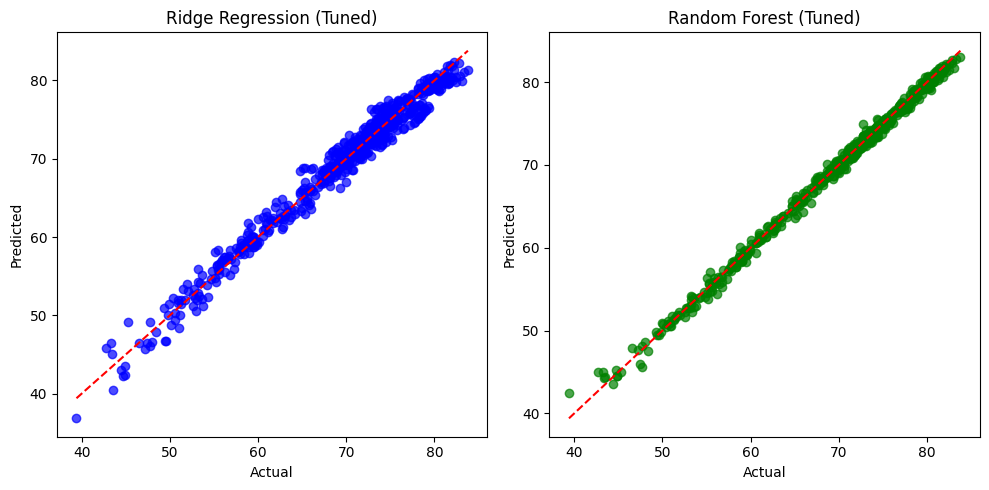

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_ridge, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Ridge Regression (Tuned)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf_tuned, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest (Tuned)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

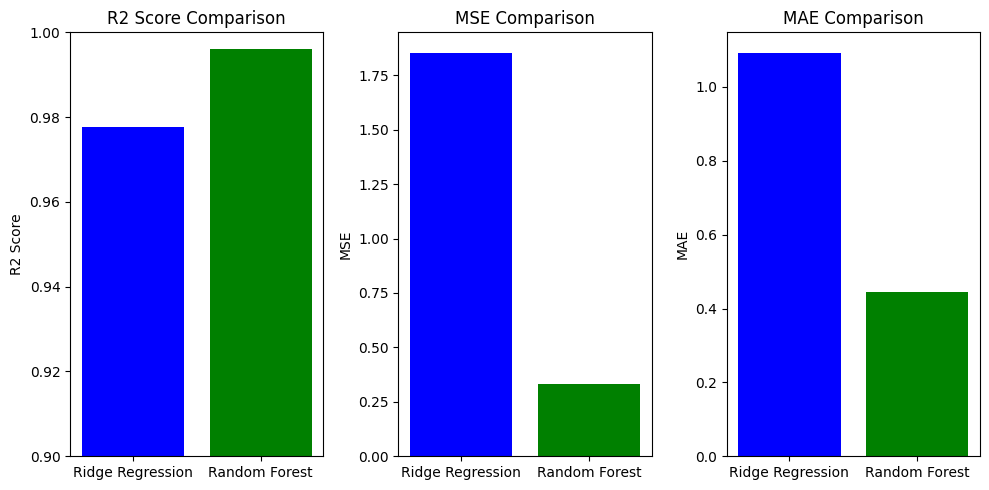

In [ ]:
models = ['Ridge Regression', 'Random Forest']
r2_scores = [r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_rf_tuned)]
mse_scores = [mean_squared_error(y_test, y_pred_ridge), mean_squared_error(y_test, y_pred_rf_tuned)]
mae_scores = [mean_absolute_error(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_rf_tuned)]

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].bar(models, r2_scores, color=['blue', 'green'])
axes[0].set_title('R2 Score Comparison')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim([0.9, 1.0])

axes[1].bar(models, mse_scores, color=['blue', 'green'])
axes[1].set_title('MSE Comparison')
axes[1].set_ylabel('MSE')

axes[2].bar(models, mae_scores, color=['blue', 'green'])
axes[2].set_title('MAE Comparison')
axes[2].set_ylabel('MAE')

plt.tight_layout()
plt.show()

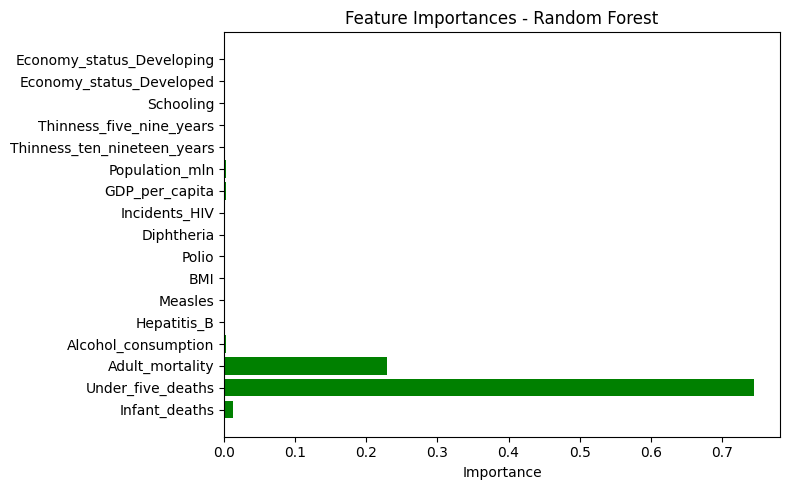

In [ ]:
feature_names = X.columns
importances = best_rf.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='green')
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()